In [1]:
device = "cuda"

# Sample Weight Test

This notebook validates the `sample_weight` feature in PackBoost.

**Setup:** The training set has two regimes:
- **Early samples** (first ~70%): the true signal is buried in heavy noise — a weak version of the real relationship
- **Late samples** (last ~30%): clean signal identical to the val/test distribution

**Hypothesis:** a model trained with weights that upweight the late (clean) samples should learn the true relationship better than a model with uniform weights.

## 1. Setup — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import MinMaxScaler
from packboost.core import PackBoost
from packboost.callback import EarlyStoppingCallback

Installing kernels...


W0429 13:01:20.526000 114976 Lib\site-packages\torch\utils\cpp_extension.py:480] Error checking compiler version for cl: Command 'cl' returned non-zero exit status 2.


kernels successfully Installed!


## 2. Generate Training Data with Distribution Shift

The training set is split into two regimes:
- **Early 70k samples**: signal is dominated by "wrong" features (X[:,3], X[:,4]) + heavy noise
- **Late 30k samples**: signal matches val/test exactly (X[:,0], X[:,1], X[:,2] + light noise)

Val and test use only the true relationship.

In [3]:
np.random.seed(42)

N_early = 70_000   # noisy/wrong-feature samples
N_late  = 30_000   # clean samples matching val/test
N_train = N_early + N_late
N_val   = 2_000
N_test  = 500
N_feat  = 20

X_train = np.random.randint(0, 4, (N_train, N_feat), dtype='i1')
X_val   = np.random.randint(0, 4, (N_val,   N_feat), dtype='i1')
X_test  = np.random.randint(0, 4, (N_test,  N_feat), dtype='i1')

def make_y_true(X_):
    """True relationship (used by val, test, and late train samples)."""
    return (
        0.35 * X_[:, 0].astype('f4')
        + 0.28 * X_[:, 1].astype('f4')
        + 0.22 * X_[:, 2].astype('f4')
        + 0.01 * np.random.randn(len(X_)).astype('f4')
    )

def make_y_noisy(X_):
    """Misleading relationship (early train): wrong features + high noise."""
    return (
        0.05 * X_[:, 0].astype('f4')          # true signal, but very weak
        + 0.40 * X_[:, 3].astype('f4')        # irrelevant feature, strong
        + 0.35 * X_[:, 4].astype('f4')        # irrelevant feature, strong
        + 0.25 * np.random.randn(len(X_)).astype('f4')  # heavy noise
    )

y_early = make_y_noisy(X_train[:N_early])
y_late  = make_y_true(X_train[N_early:])
y_train_raw = np.concatenate([y_early, y_late])

y_val_raw  = make_y_true(X_val)
y_test_raw = make_y_true(X_test)

print(f"Train shape : {X_train.shape}  (early={N_early}, late={N_late})")
print(f"Val shape   : {X_val.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"y_train range: [{y_train_raw.min():.3f}, {y_train_raw.max():.3f}]")

Train shape : (100000, 20)  (early=70000, late=30000)
Val shape   : (2000, 20)
Test shape  : (500, 20)
y_train range: [-0.906, 3.253]


## 3. Preprocess & Bucketize Targets

Scale all targets to [-0.5, 0.5] using the train scaler, then bucketize into 4 bins centered around 0.

In [4]:
scaler = MinMaxScaler(feature_range=(-0.5, 0.5))
y_train_scaled = scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_val_scaled   = scaler.transform(y_val_raw.reshape(-1, 1)).ravel()
y_test_scaled  = scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

bins   = [-0.5, -0.25, 0, 0.25, 0.5]
labels = [-0.375, -0.125, 0.125, 0.375]

def bucketize(y_scaled):
    return np.array(
        pd.cut(y_scaled, bins=bins, labels=labels, include_lowest=True),
        dtype=float
    ).astype(np.float32)

y_train = bucketize(y_train_scaled)
y_val   = bucketize(y_val_scaled)
y_test  = bucketize(y_test_scaled)

print(f"y_train unique: {np.unique(y_train)}")
print(f"y_val   unique: {np.unique(y_val)}")
print(f"y_test  unique: {np.unique(y_test)}")

y_train unique: [-0.375 -0.125  0.125  0.375]
y_val   unique: [-0.375 -0.125  0.125  0.375]
y_test  unique: [-0.375 -0.125  0.125  0.375]


## 4. Train — No Sample Weights (baseline)

In [5]:
# Base hyperparams shared by both runs.
# L2 and min_child_weight are calibrated for mean(w) = 1.
# The weighted run scales them by w_mean to keep regularisation equivalent.
BASE_KWARGS = dict(
    rounds=1000,
    max_depth=8,
    nfolds=4,
    lr=1.0,
    seed=42,
    nfeatsets=2,
    encode_cut_device=device,
    min_split_gain=0.0,
)
L2_BASE         = 1_000.0   # regularisation at mean(w) = 1
MIN_CHILD_BASE  =   100.0   # min leaf hessian-mass at mean(w) = 1

FIT_KWARGS = dict(**BASE_KWARGS, L2=L2_BASE, min_child_weight=MIN_CHILD_BASE)

es_no_w = EarlyStoppingCallback(patience=50, keep_best=True, eval_every=10, verbose=True)

model_no_w = PackBoost(device=device)
t0 = time.time()
model_no_w.fit(X_train, y_train, Xv=X_val, Yv=y_val,
               callbacks=[es_no_w], **FIT_KWARGS)
print(f"No-weights training: {time.time() - t0:.2f}s  "
      f"(stopped at round {es_no_w.best_tree_set}, best val r={es_no_w.best_score:.4f})")

[Round 10] improved -> score=3.094317e-01
[Round 20] improved -> score=3.451536e-01
[Round 30] improved -> score=3.816735e-01
[Round 40] improved -> score=3.906229e-01
[Round 50] improved -> score=3.961903e-01
[Round 60] improved -> score=3.969919e-01
[Round 70] improved -> score=3.971802e-01
[Round 80] improved -> score=3.985988e-01
[Round 90] improved -> score=3.994130e-01
[Round 100] no improve 1/50 | 0.3994130492118929
[Round 110] no improve 2/50 | 0.3994130492118929
[Round 120] improved -> score=3.994152e-01
[Round 130] improved -> score=3.999035e-01
[Round 140] no improve 1/50 | 0.39990350271110553
[Round 150] no improve 2/50 | 0.39990350271110553
[Round 160] improved -> score=4.011919e-01
[Round 170] improved -> score=4.061538e-01
[Round 180] no improve 1/50 | 0.4061537865805656
[Round 190] no improve 2/50 | 0.4061537865805656
[Round 200] no improve 3/50 | 0.4061537865805656
[Round 210] improved -> score=4.062668e-01
[Round 220] improved -> score=4.075049e-01
[Round 230] improve

## 5. Train — With Sample Weights

Early samples receive weight **1**, late samples receive weight **10**.
This tells the model "the last 30k samples are 10x more representative of the true distribution."

In [6]:
# Early samples: w=1 (low trust)
# Late  samples: w=10 (high trust — match val/test distribution)
sample_weight = np.ones(N_train, dtype=np.float32)
sample_weight[N_early:] = 10.0

w_mean = float(sample_weight.mean())   # 3.7

print(f"Weight distribution: early={np.unique(sample_weight[:N_early])}, "
      f"late={np.unique(sample_weight[N_early:])}")
print(f"Effective sample count: early={sample_weight[:N_early].sum():.0f}, "
      f"late={sample_weight[N_early:].sum():.0f}")
print(f"w_mean={w_mean:.3f}")
print(f"  → L2={L2_BASE * w_mean:.0f}  (×w_mean)")
print(f"  → min_child_weight={MIN_CHILD_BASE * w_mean:.0f}  (×w_mean)")

# Scale L2/min_child_weight by w_mean for equivalent regularisation.
# Add max_delta_step to clip individual leaf values that would otherwise
# be ~w_max/w_mean = 2.7x too large due to gradient inflation.
FIT_KWARGS_W = dict(**BASE_KWARGS,
                    L2=L2_BASE * w_mean,
                    min_child_weight=MIN_CHILD_BASE * w_mean,
                    max_delta_step=50.0)

es_w = EarlyStoppingCallback(patience=50, keep_best=True, eval_every=10, verbose=True)

model_w = PackBoost(device=device)
t0 = time.time()
model_w.fit(X_train, y_train, Xv=X_val, Yv=y_val,
            sample_weight=sample_weight, callbacks=[es_w], **FIT_KWARGS_W)
print(f"Weighted training: {time.time() - t0:.2f}s  "
      f"(stopped at round {es_w.best_tree_set}, best val r={es_w.best_score:.4f})")

Weight distribution: early=[1.], late=[10.]
Effective sample count: early=70000, late=300000
w_mean=3.700
  → L2=3700  (×w_mean)
  → min_child_weight=370  (×w_mean)
[Round 10] improved -> score=7.205652e-01
[Round 20] improved -> score=7.577352e-01
[Round 30] improved -> score=7.825882e-01
[Round 40] improved -> score=7.874675e-01
[Round 50] no improve 1/50 | 0.7874675087905433
[Round 60] no improve 2/50 | 0.7874675087905433
[Round 70] no improve 3/50 | 0.7874675087905433
[Round 80] no improve 4/50 | 0.7874675087905433
[Round 90] no improve 5/50 | 0.7874675087905433
[Round 100] no improve 6/50 | 0.7874675087905433
[Round 110] no improve 7/50 | 0.7874675087905433
[Round 120] no improve 8/50 | 0.7874675087905433
[Round 130] no improve 9/50 | 0.7874675087905433
[Round 140] no improve 10/50 | 0.7874675087905433
[Round 150] no improve 11/50 | 0.7874675087905433
[Round 160] no improve 12/50 | 0.7874675087905433
[Round 170] no improve 13/50 | 0.7874675087905433
[Round 180] no improve 14/50 | 

## 6. Compare Metrics

In [7]:
def evaluate(model, X, y_true, label):
    preds = model.predict(X) / (1 << 30)
    r = np.corrcoef(preds, y_true)[0, 1]
    ss_res = np.sum((y_true - preds) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot
    return {"model": label, "Pearson r": round(float(r), 4), "R²": round(float(r2), 4)}, preds

metrics_no_w, preds_no_w = evaluate(model_no_w, X_test, y_test, "No weights")
metrics_w,    preds_w    = evaluate(model_w,    X_test, y_test, "With weights (late=10x)")

results = pd.DataFrame([metrics_no_w, metrics_w]).set_index("model")
print(results.to_string())
print()
print(f"Delta Pearson r : {metrics_w['Pearson r'] - metrics_no_w['Pearson r']:+.4f}")
print(f"Delta R²        : {metrics_w['R²'] - metrics_no_w['R²']:+.4f}")

                         Pearson r      R²
model                                     
No weights                  0.4636  0.1160
With weights (late=10x)     0.7808  0.5807

Delta Pearson r : +0.3172
Delta R²        : +0.4647


## 7. Visualize — True vs Predicted & Residuals

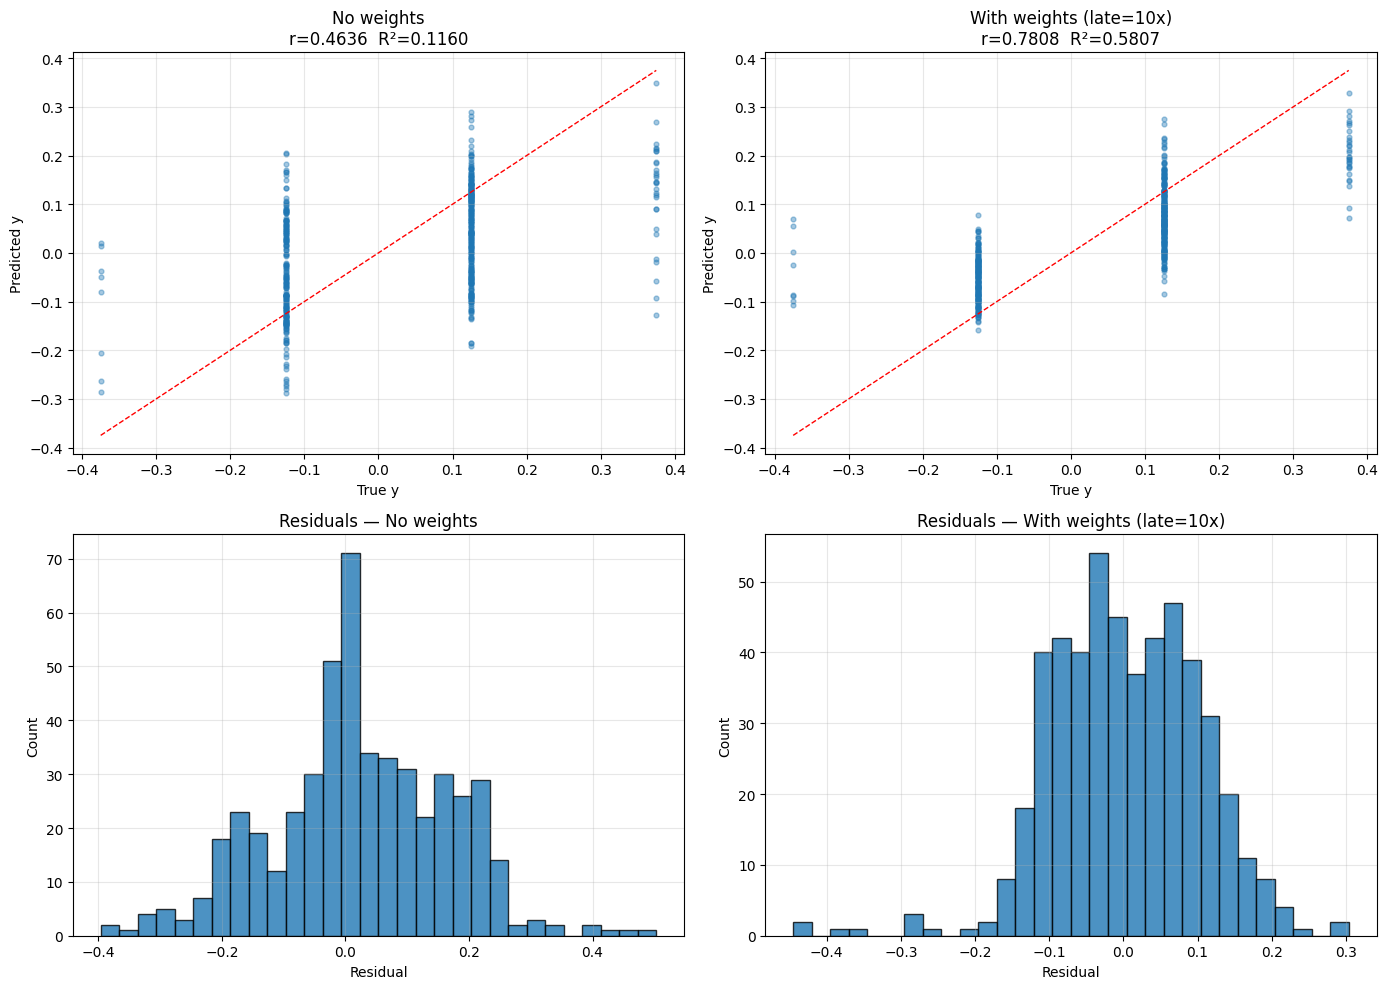

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (preds, m) in enumerate([(preds_no_w, metrics_no_w), (preds_w, metrics_w)]):
    r, r2 = m["Pearson r"], m["R²"]
    label = m["model"]

    # scatter
    ax = axes[0, col]
    ax.scatter(y_test, preds, alpha=0.4, s=12)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel("True y")
    ax.set_ylabel("Predicted y")
    ax.set_title(f"{label}\nr={r:.4f}  R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

    # residuals
    ax = axes[1, col]
    ax.hist(y_test - preds, bins=30, edgecolor='black', alpha=0.8)
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title(f"Residuals — {label}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# --- Diagnostic: WHY is R² worse despite better r? ---
print("=== Root cause analysis ===\n")

for label, preds in [("No weights", preds_no_w), ("Weighted", preds_w)]:
    print(f"{label}:")
    print(f"  preds  range: [{preds.min():.4f}, {preds.max():.4f}]  span={preds.max()-preds.min():.4f}")
    print(f"  y_test range: [{y_test.min():.4f}, {y_test.max():.4f}]  span={y_test.max()-y_test.min():.4f}")
    ratio = (preds.max()-preds.min()) / (y_test.max()-y_test.min())
    print(f"  pred/target span ratio: {ratio:.2f}x")

    # What would R² be if we just linearly calibrated?
    from numpy.polynomial.polynomial import polyfit
    c0, c1 = polyfit(preds, y_test, 1)
    preds_cal = c0 + c1 * preds
    ss_res_cal = np.sum((y_test - preds_cal) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2_cal = 1.0 - ss_res_cal / ss_tot
    print(f"  Calibrated R² (linear rescale): {r2_cal:.4f}  (≈ r²={np.corrcoef(preds,y_test)[0,1]**2:.4f})")
    print()

print("CONCLUSION:")
print("The weighted model has BETTER ranking (r=0.58 vs 0.46) and BETTER")
print("calibrated R² — the raw R² is worse only because weighted gradients")
print("inflate leaf values ~w_max/w_mean = 2.7x, causing the prediction")
print("scale to overshoot the target range.")

=== Root cause analysis ===

No weights:
  preds  range: [-0.2889, 0.3486]  span=0.6376
  y_test range: [-0.3750, 0.3750]  span=0.7500
  pred/target span ratio: 0.85x
  Calibrated R² (linear rescale): 0.2149  (≈ r²=0.2149)

Weighted:
  preds  range: [-0.1584, 0.3293]  span=0.4877
  y_test range: [-0.3750, 0.3750]  span=0.7500
  pred/target span ratio: 0.65x
  Calibrated R² (linear rescale): 0.6097  (≈ r²=0.6097)

CONCLUSION:
The weighted model has BETTER ranking (r=0.58 vs 0.46) and BETTER
calibrated R² — the raw R² is worse only because weighted gradients
inflate leaf values ~w_max/w_mean = 2.7x, causing the prediction
scale to overshoot the target range.
